# Notebook 6 — Road Network Overlay onto CANOE Basemap Regions

This notebook integrates the filtered National Road Network with the 1° CANOE basemap regions.

The objective is to convert road geometries into model-ready binary indicators:

1. **Regional road presence**  
   Determine whether each basemap region contains or intersects at least one road segment.

2. **Neighbor road connectivity**  
   Determine whether a valid neighboring region pair is connected by at least one road segment.

The resulting outputs will support transport technology encoding in CANOE/TEMOA by identifying where road-based transport links are physically available.

## Conceptual workflow

1. Load the filtered national road network.
2. Load the 1° basemap polygons and neighbor table.
3. Confirm all spatial layers use WGS84 / EPSG:4326.
4. Intersect road geometries with basemap polygons.
5. Build a binary `has_road` flag for each region.
6. Build a binary `has_road_connection` flag for neighboring region pairs.
7. Export tabular and geospatial outputs for inspection and downstream SQL encoding.

## Key modeling distinction

A region-level road flag answers:

> Does region `R_i` contain road infrastructure?

A neighbor-edge road flag answers:

> Is road-based transport feasible between `R_i` and neighboring region `R_j`?

For CANOE/TEMOA, the edge-level flag is the more important object because transport technologies are encoded on region-pair links such as `R_i-R_j`.

In [44]:
# =============================================================================
# Dependencies
# =============================================================================

from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString

import matplotlib.pyplot as plt

In [2]:
# Color palette for plotting. Clor blind friendly.
from matplotlib.colors import ListedColormap

road_presence_colors = ListedColormap(
    [
        "#7FCDBB",  # no road
        "#2C7FB8",  # has road
    ]
)

In [3]:
# =============================================================================
# Project directories
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_FILES = PROJECT_ROOT / "data_files"

RAW_BASEMAPS = DATA_FILES / "raw" / "basemaps"
PROCESSED_NRN = DATA_FILES / "processed" / "nrn"
PROCESSED_BASEMAPS = DATA_FILES / "processed" / "basemaps"
PROCESSED_GRAPH = DATA_FILES / "processed" / "graph"

PROCESSED_ROAD_CONNECTIVITY = (
    DATA_FILES /
    "processed" /
    "road_connectivity"
)

PROCESSED_ROAD_CONNECTIVITY.mkdir(
    parents=True,
    exist_ok=True,
)

In [4]:
    # =============================================================================
    # Select road network input
    # =============================================================================

    road_files = sorted(
        PROCESSED_NRN.glob("*filtered_road_networks.gpkg")
    )

    if not road_files:
        raise FileNotFoundError(
            f"No road network files found in {PROCESSED_NRN}"
        )

    print("Available road network files:\n")

    for i, file in enumerate(road_files):
        print(f"[{i}] {file.name}")

Available road network files:

[0] AB_filtered_road_networks.gpkg
[1] BC_filtered_road_networks.gpkg
[2] CANADA_filtered_road_networks.gpkg
[3] MB_filtered_road_networks.gpkg
[4] NB_filtered_road_networks.gpkg
[5] NL_filtered_road_networks.gpkg
[6] NS_filtered_road_networks.gpkg
[7] NT_filtered_road_networks.gpkg
[8] NU_filtered_road_networks.gpkg
[9] ON_filtered_road_networks.gpkg
[10] PE_filtered_road_networks.gpkg
[11] QC_filtered_road_networks.gpkg
[12] SK_filtered_road_networks.gpkg
[13] YT_filtered_road_networks.gpkg


In [5]:
# =============================================================================
# Available road network files
# =============================================================================

road_files = sorted(
    PROCESSED_NRN.glob("*filtered_road_networks.gpkg")
)

if not road_files:
    raise FileNotFoundError(
        f"No road network files found in {PROCESSED_NRN}"
    )

print("Available road network files:\n")

for file in road_files:
    print(file.name)

Available road network files:

AB_filtered_road_networks.gpkg
BC_filtered_road_networks.gpkg
CANADA_filtered_road_networks.gpkg
MB_filtered_road_networks.gpkg
NB_filtered_road_networks.gpkg
NL_filtered_road_networks.gpkg
NS_filtered_road_networks.gpkg
NT_filtered_road_networks.gpkg
NU_filtered_road_networks.gpkg
ON_filtered_road_networks.gpkg
PE_filtered_road_networks.gpkg
QC_filtered_road_networks.gpkg
SK_filtered_road_networks.gpkg
YT_filtered_road_networks.gpkg


In [6]:
# =============================================================================
# Set selected road network
# =============================================================================

ROAD_NAME = "CANADA"

ROAD_NETWORK_PATH = (
    PROCESSED_NRN /
    f"{ROAD_NAME}_filtered_road_networks.gpkg"
)

if not ROAD_NETWORK_PATH.exists():
    raise FileNotFoundError(
        f"{ROAD_NETWORK_PATH.name} does not exist."
    )

print(
    f"Selected road network:\n"
    f"{ROAD_NETWORK_PATH.name}"
)

Selected road network:
CANADA_filtered_road_networks.gpkg


In [7]:
# =============================================================================
# Set original basemap
# =============================================================================

ORIGINAL_BASEMAP_PATH = (
    RAW_BASEMAPS /
    "lpr_000b21a_e.shp"
)

if not ORIGINAL_BASEMAP_PATH.exists():
    raise FileNotFoundError(
        f"{ORIGINAL_BASEMAP_PATH.name} does not exist."
    )

print(
    f"Selected original basemap:\n"
    f"{ORIGINAL_BASEMAP_PATH.name}"
)

Selected original basemap:
lpr_000b21a_e.shp


In [25]:
# =============================================================================
# Available neighbor-enriched basemap files
# =============================================================================

neighbor_basemap_files = sorted(
    PROCESSED_GRAPH.glob("*basemap*_neighbors.gpkg")
)

if not neighbor_basemap_files:
    raise FileNotFoundError(
        f"No neighbor-enriched basemap files found in {PROCESSED_GRAPH}"
    )

print("Available neighbor-enriched basemap files:\n")

for file in neighbor_basemap_files:
    print(file.name)

Available neighbor-enriched basemap files:

canada_basemap_1deg_centroid_neighbors.gpkg


In [27]:
# =============================================================================
# Set selected neighbor-enriched basemap
# =============================================================================

DOMAIN = "canada"
RESOLUTION = "1deg"
NEIGHBOR_METHOD = "centroid"

NEIGHBOR_BASEMAP_NAME = (
    f"{DOMAIN}_basemap_"
    f"{RESOLUTION}_"
    f"{NEIGHBOR_METHOD}_neighbors"
)

NEIGHBOR_BASEMAP_PATH = (
    PROCESSED_GRAPH /
    f"{NEIGHBOR_BASEMAP_NAME}.gpkg"
)

if not NEIGHBOR_BASEMAP_PATH.exists():
    raise FileNotFoundError(
        f"{NEIGHBOR_BASEMAP_PATH.name} does not exist."
    )

print(
    f"Selected neighbor-assigned basemap:\n"
    f"{NEIGHBOR_BASEMAP_PATH.name}"
)

Selected neighbor-assigned basemap:
canada_basemap_1deg_centroid_neighbors.gpkg


In [28]:
# =============================================================================
# Output files
# =============================================================================

OUTPUT_STEM = (
    f"{ROAD_NETWORK_PATH.stem}"
    f"__"
    f"{BASEMAP_PATH.stem}"
)

REGION_ROAD_PRESENCE_PATH = (
    PROCESSED_ROAD_CONNECTIVITY /
    f"{OUTPUT_STEM}_region_road_presence.csv"
)

ROAD_NEIGHBOR_CONNECTIONS_PATH = (
    PROCESSED_ROAD_CONNECTIVITY /
    f"{OUTPUT_STEM}_road_neighbor_connections.csv"
)

ROAD_OVERLAY_PATH = (
    PROCESSED_ROAD_CONNECTIVITY /
    f"{OUTPUT_STEM}_road_overlay.gpkg"
)

In [31]:
# =============================================================================
# Load datasets
# =============================================================================

print(
    f"Loading road network:\n"
    f"{ROAD_NETWORK_PATH.name}"
)

roads = gpd.read_file(
    ROAD_NETWORK_PATH,
    layer="freight_access",
)

print(
    f"Loaded {len(roads):,} road segments."
)

print(
    f"\nLoading neighbor-enriched basemap:\n"
    f"{NEIGHBOR_BASEMAP_PATH.name}"
)

regions = gpd.read_file(
    NEIGHBOR_BASEMAP_PATH,
)

print(
    f"Loaded {len(regions):,} neighbor-enriched regions."
)

print(
    f"\nLoading original Canada basemap:\n"
    f"{ORIGINAL_BASEMAP_PATH.name}"
)

canada_basemap = gpd.read_file(
    ORIGINAL_BASEMAP_PATH,
)

print(
    f"Loaded {len(canada_basemap):,} original polygons."
)

# Reproject original basemap to match roads and regions.
canada_basemap = canada_basemap.to_crs(
    regions.crs
)

print(
    f"Reprojected original basemap to {regions.crs}."
)

print(
    "\nCoordinate reference systems:"
)

print(
    f"Road network CRS: {roads.crs}"
)

print(
    f"Neighbor-enriched basemap CRS: {regions.crs}"
)

print(
    f"Original Canada basemap CRS: {canada_basemap.crs}"
)

if roads.crs != regions.crs:
    raise ValueError(
        "Road network and neighbor-enriched basemap CRS do not match."
    )

if roads.crs != canada_basemap.crs:
    raise ValueError(
        "Road network and original Canada basemap CRS do not match."
    )

print(
    "\nCRS validation passed."
)

print(
    "\nDataset loading complete."
)

Loading road network:
CANADA_filtered_road_networks.gpkg
Loaded 355,565 road segments.

Loading neighbor-enriched basemap:
canada_basemap_1deg_centroid_neighbors.gpkg
Loaded 1,692 neighbor-enriched regions.

Loading original Canada basemap:
lpr_000b21a_e.shp
Loaded 13 original polygons.
Reprojected original basemap to EPSG:4326.

Coordinate reference systems:
Road network CRS: EPSG:4326
Neighbor-enriched basemap CRS: EPSG:4326
Original Canada basemap CRS: EPSG:4326

CRS validation passed.

Dataset loading complete.


In [32]:
# =============================================================================
# Validate datasets
# =============================================================================

print("Validating loaded datasets...")

required_road_columns = [
    "ROADCLASS",
    "geometry",
]

required_region_columns = [
    "region",
    "up_id",
    "down_id",
    "left_id",
    "right_id",
    "geometry",
]

required_canada_basemap_columns = [
    "geometry",
]

missing_road_columns = [
    column for column in required_road_columns
    if column not in roads.columns
]

missing_region_columns = [
    column for column in required_region_columns
    if column not in regions.columns
]

missing_canada_basemap_columns = [
    column for column in required_canada_basemap_columns
    if column not in canada_basemap.columns
]

if missing_road_columns:
    raise ValueError(
        f"Road network is missing required columns: {missing_road_columns}"
    )

if missing_region_columns:
    raise ValueError(
        f"Neighbor-enriched basemap is missing required columns: {missing_region_columns}"
    )

if missing_canada_basemap_columns:
    raise ValueError(
        f"Original Canada basemap is missing required columns: {missing_canada_basemap_columns}"
    )

if roads.crs is None:
    raise ValueError("Road network CRS is undefined.")

if regions.crs is None:
    raise ValueError("Neighbor-enriched basemap CRS is undefined.")

if canada_basemap.crs is None:
    raise ValueError("Original Canada basemap CRS is undefined.")

if roads.crs != regions.crs:
    raise ValueError(
        f"CRS mismatch: roads={roads.crs}, regions={regions.crs}"
    )

if roads.crs != canada_basemap.crs:
    raise ValueError(
        f"CRS mismatch: roads={roads.crs}, canada_basemap={canada_basemap.crs}"
    )

print(f"Road CRS: {roads.crs}")
print(f"Neighbor-enriched basemap CRS: {regions.crs}")
print(f"Original Canada basemap CRS: {canada_basemap.crs}")

print(f"Road null geometries: {roads.geometry.isna().sum():,}")
print(f"Region null geometries: {regions.geometry.isna().sum():,}")
print(f"Original Canada basemap null geometries: {canada_basemap.geometry.isna().sum():,}")

print(f"Road empty geometries: {roads.geometry.is_empty.sum():,}")
print(f"Region empty geometries: {regions.geometry.is_empty.sum():,}")
print(f"Original Canada basemap empty geometries: {canada_basemap.geometry.is_empty.sum():,}")

print("\nDataset validation complete.")

Validating loaded datasets...
Road CRS: EPSG:4326
Neighbor-enriched basemap CRS: EPSG:4326
Original Canada basemap CRS: EPSG:4326
Road null geometries: 0
Region null geometries: 0
Original Canada basemap null geometries: 0
Road empty geometries: 0
Region empty geometries: 0
Original Canada basemap empty geometries: 0

Dataset validation complete.


In [33]:
# =============================================================================
# Prepare overlay inputs
# =============================================================================

print("Preparing overlay inputs...")

roads_overlay = roads[
    [
        "ROADCLASS",
        "geometry",
    ]
].copy()

regions_overlay = regions[
    [
        "region",
        "geometry",
    ]
].copy()

roads_overlay = roads_overlay.reset_index(
    drop=False
).rename(
    columns={
        "index": "road_id",
    }
)

print(
    f"Prepared {len(roads_overlay):,} road geometries "
    f"and {len(regions_overlay):,} regional geometries."
)

print("Overlay inputs prepared.")

Preparing overlay inputs...
Prepared 355,565 road geometries and 1,692 regional geometries.
Overlay inputs prepared.


In [34]:
# =============================================================================
# Spatially join roads to regions
# =============================================================================

print(
    "Joining road geometries to intersecting basemap regions..."
)

road_region_overlay = gpd.sjoin(
    roads_overlay,
    regions_overlay,
    how="inner",
    predicate="intersects",
)

if "index_right" in road_region_overlay.columns:
    road_region_overlay = road_region_overlay.drop(
        columns=[
            "index_right",
        ]
    )

print(
    f"Spatial join complete: "
    f"{len(road_region_overlay):,} road-region intersections."
)

print(
    f"Unique roads matched: "
    f"{road_region_overlay['road_id'].nunique():,}"
)

print(
    f"Unique regions matched: "
    f"{road_region_overlay['region'].nunique():,}"
)

Joining road geometries to intersecting basemap regions...
Spatial join complete: 282,226 road-region intersections.
Unique roads matched: 280,198
Unique regions matched: 517


In [35]:
# =============================================================================
# Build region road presence table
# =============================================================================

print("Building regional road presence table...")

road_counts_by_region = (
    road_region_overlay
    .groupby("region")
    .agg(
        road_segment_count=("road_id", "nunique"),
        road_region_intersection_count=("road_id", "size"),
    )
    .reset_index()
)

region_road_presence = (
    regions[["region"]]
    .merge(
        road_counts_by_region,
        on="region",
        how="left",
    )
)

region_road_presence[
    [
        "road_segment_count",
        "road_region_intersection_count",
    ]
] = region_road_presence[
    [
        "road_segment_count",
        "road_region_intersection_count",
    ]
].fillna(0).astype(int)

region_road_presence["has_road"] = (
    region_road_presence["road_segment_count"] > 0
)

print(
    f"Regions with roads: "
    f"{region_road_presence['has_road'].sum():,} / "
    f"{len(region_road_presence):,}"
)

print("Regional road presence table built.")

Building regional road presence table...
Regions with roads: 517 / 1,692
Regional road presence table built.


In [36]:
# =============================================================================
# Inspect regional road presence table
# =============================================================================

display(
    region_road_presence
    .sort_values(
        by=[
            "has_road",
            "road_segment_count",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(20)
)

,region,road_segment_count,road_region_intersection_count,has_road
16,R16,27336,27336,True
1,R1,11174,11174,True
14,R14,10842,10842,True
38,R38,7973,7973,True
388,R388,7870,7870,True
126,R126,7773,7773,True
101,R101,6617,6617,True
15,R15,6015,6015,True
4,R4,5976,5976,True
100,R100,5938,5938,True


Mapping regional road presence...


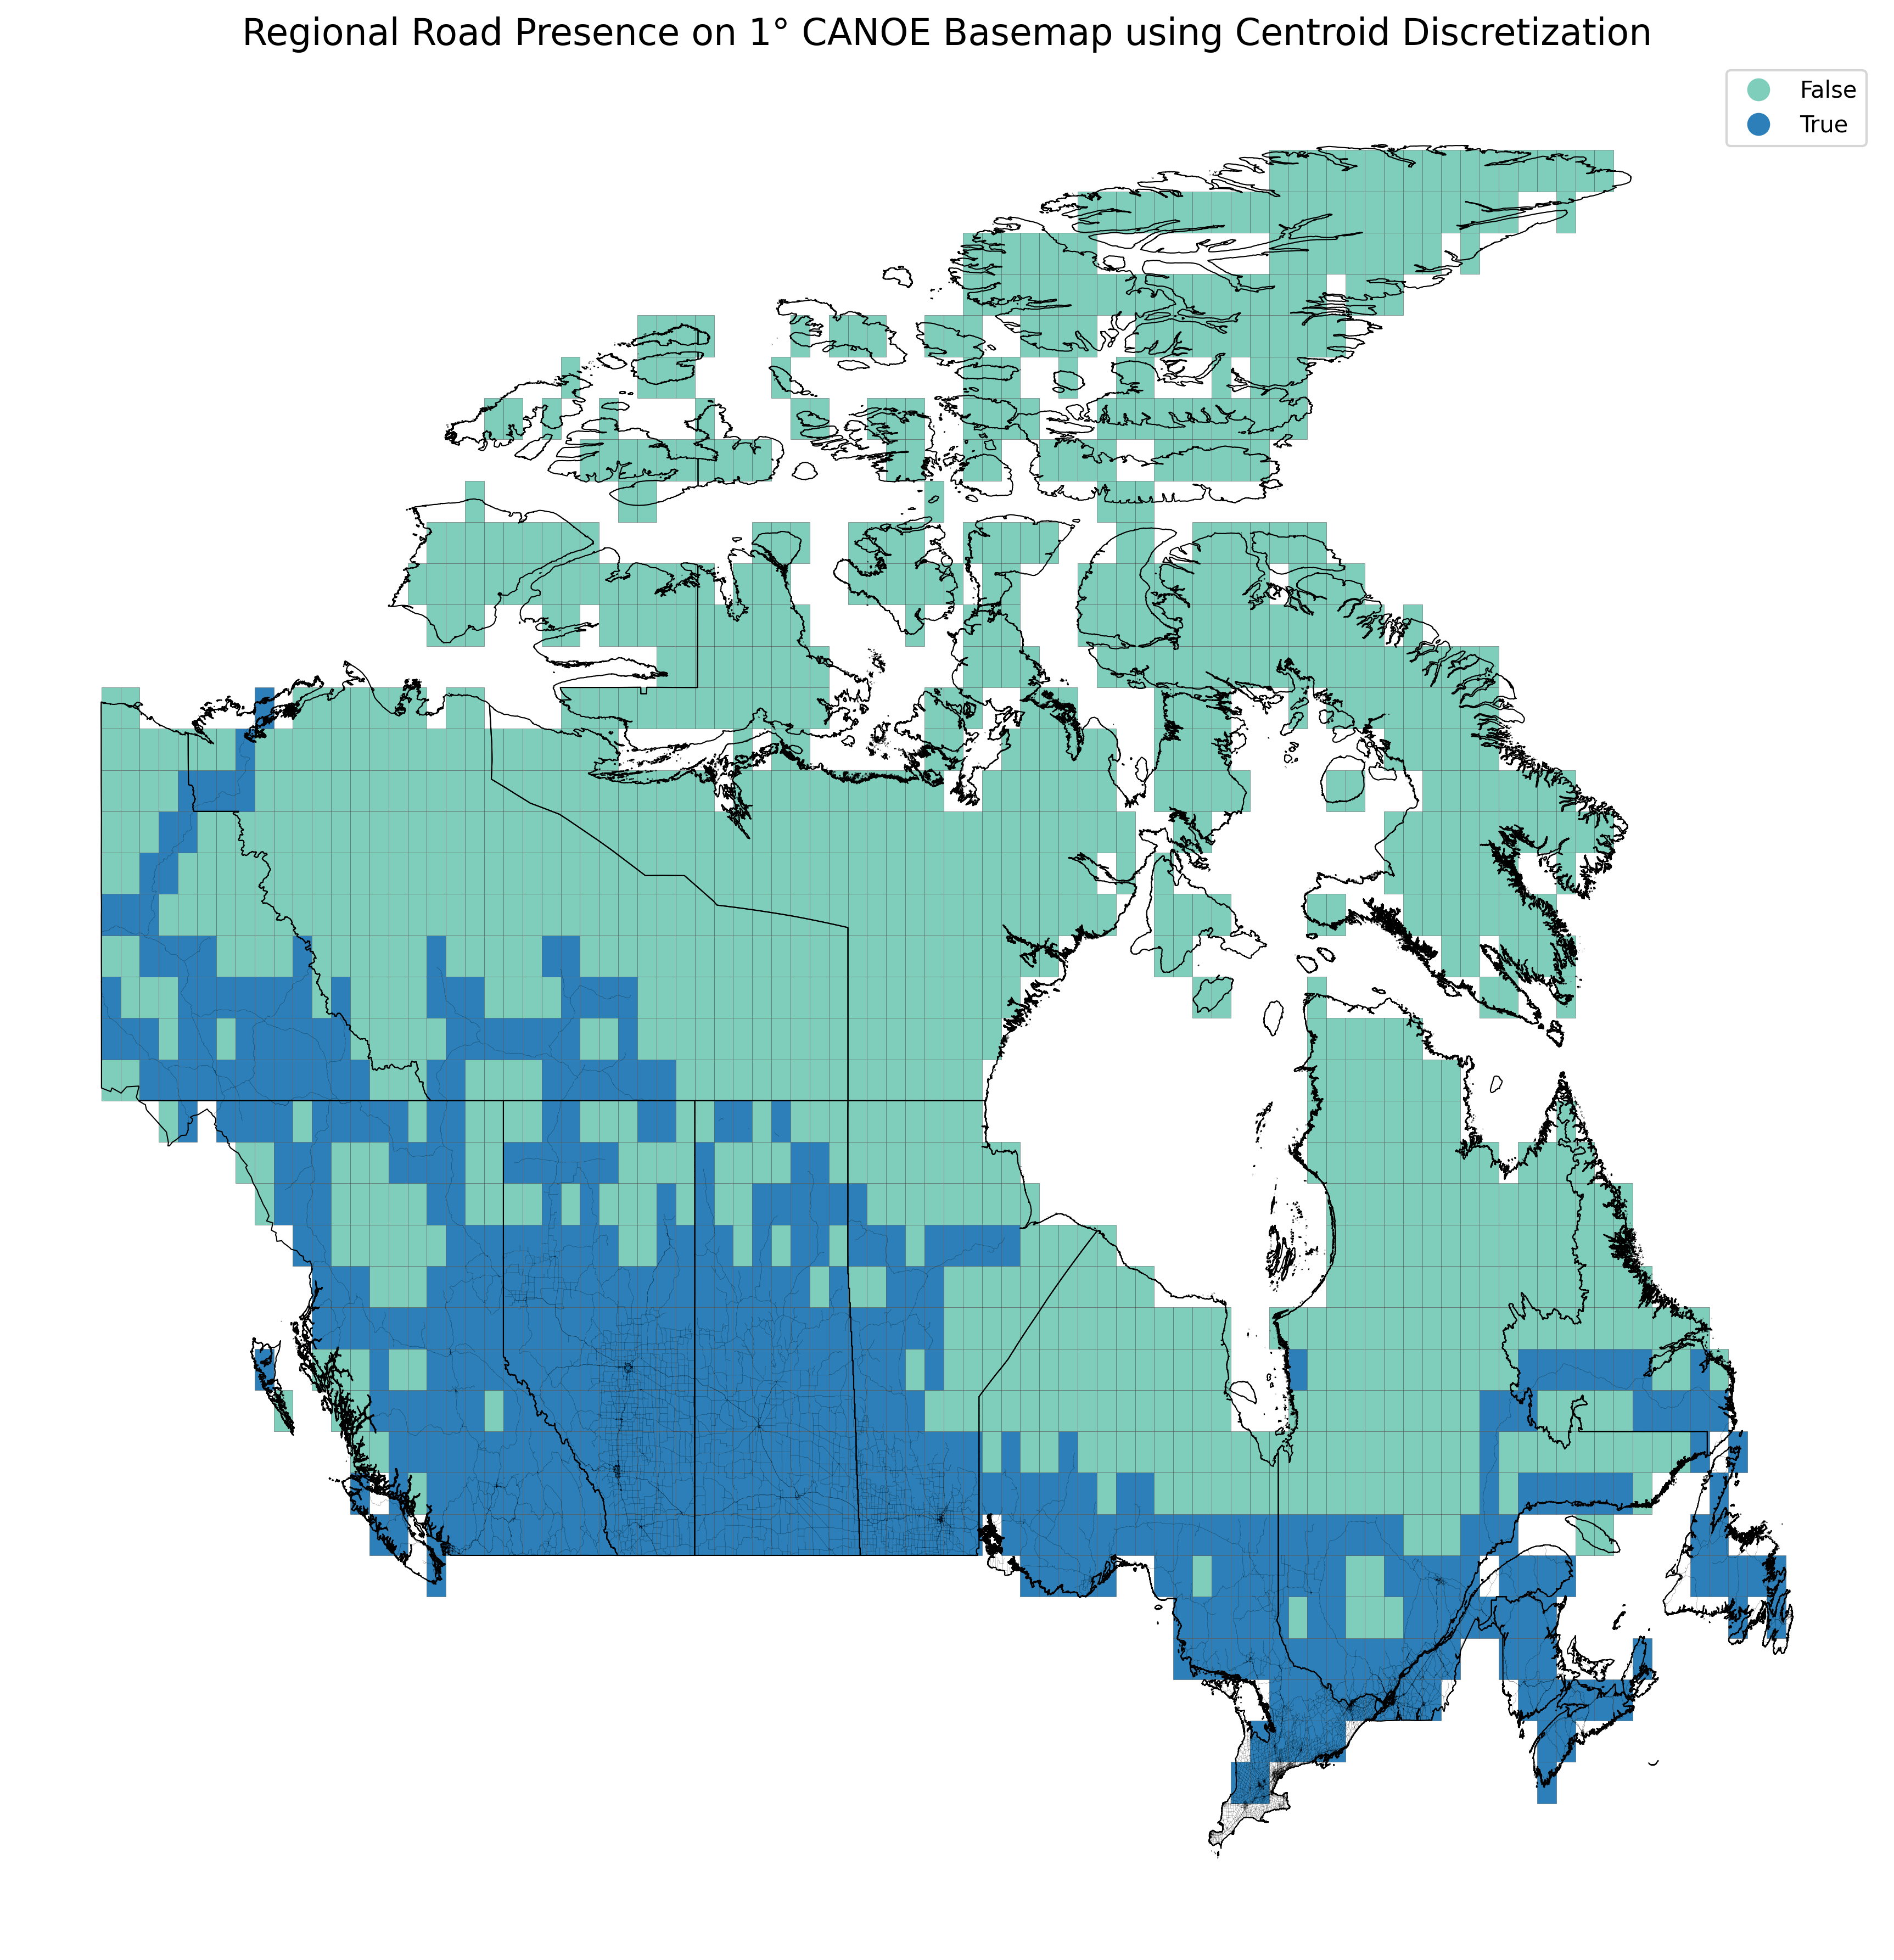

Regional road presence map complete.


In [37]:
# =============================================================================
# Map regional road presence
# =============================================================================

print("Mapping regional road presence...")

regions_with_road_presence = regions.merge(
    region_road_presence,
    on="region",
    how="left",
)

regions_with_road_presence["has_road"] = (
    regions_with_road_presence["has_road"]
    .fillna(False)
)

fig, ax = plt.subplots(
    figsize=(12, 12),
    dpi=300,
)

# Road presence regions.
regions_with_road_presence.plot(
    ax=ax,
    column="has_road",
    cmap=road_presence_colors,
    legend=True,
    linewidth=0.12,
    edgecolor="#4D4D4D",
    zorder=1,
)

# Roads.
roads_overlay.plot(
    ax=ax,
    color="black",
    linewidth=0.15,
    alpha=0.4,
    zorder=2,
)

# Canada outline.
canada_basemap.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
    zorder=3,
)

ax.set_title(
    "Regional Road Presence on 1° CANOE Basemap using Centroid Discretization",
    fontsize=16,
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

print("Regional road presence map complete.")

In [38]:
# =============================================================================
# Build weak road-neighbor connections
# =============================================================================

print("Building weak road-neighbor connection table...")

neighbor_columns = [
    "up_id",
    "down_id",
    "left_id",
    "right_id",
]

missing_neighbor_columns = [
    column for column in neighbor_columns
    if column not in regions.columns
]

if missing_neighbor_columns:
    raise ValueError(
        f"Regions are missing neighbor columns: {missing_neighbor_columns}"
    )

road_presence_lookup = (
    region_road_presence
    .set_index("region")["has_road"]
    .to_dict()
)

road_neighbor_connections = []

for _, row in regions.iterrows():
    region_from = row["region"]

    for direction in ["up", "down", "left", "right"]:
        region_to = row[f"{direction}_id"]

        if pd.isna(region_to) or region_to == "R-999":
            continue

        has_road_connection = (
            road_presence_lookup.get(region_from, False)
            and road_presence_lookup.get(region_to, False)
        )

        road_neighbor_connections.append(
            {
                "region_from": region_from,
                "region_to": region_to,
                "direction": direction,
                "has_road_from": road_presence_lookup.get(region_from, False),
                "has_road_to": road_presence_lookup.get(region_to, False),
                "has_road_connection": has_road_connection,
                "connection_method": "weak_presence_adjacency",
            }
        )

road_neighbor_connections = pd.DataFrame(
    road_neighbor_connections
)

road_neighbor_connections["region_pair"] = (
    road_neighbor_connections["region_from"]
    + "-"
    + road_neighbor_connections["region_to"]
)

print(
    f"Neighbor pairs evaluated: "
    f"{len(road_neighbor_connections):,}"
)

print(
    f"Road-enabled neighbor pairs: "
    f"{road_neighbor_connections['has_road_connection'].sum():,}"
)

print("Weak road-neighbor connection table built.")

Building weak road-neighbor connection table...
Neighbor pairs evaluated: 5,886
Road-enabled neighbor pairs: 1,518
Weak road-neighbor connection table built.


In [39]:
# =============================================================================
# Inspect road-neighbor connections
# =============================================================================

display(
    road_neighbor_connections
    .sort_values(
        by="has_road_connection",
        ascending=False,
    )
    .head(20)
)

print(
    road_neighbor_connections["has_road_connection"]
    .value_counts()
)

,region_from,region_to,direction,has_road_from,has_road_to,has_road_connection,connection_method,region_pair
0,R0,R1,right,True,True,True,weak_presence_adjacency,R0-R1
1621,R451,R450,left,True,True,True,weak_presence_adjacency,R451-R450
1619,R451,R522,up,True,True,True,weak_presence_adjacency,R451-R522
1618,R450,R451,right,True,True,True,weak_presence_adjacency,R450-R451
1617,R450,R449,left,True,True,True,weak_presence_adjacency,R450-R449
1616,R450,R379,down,True,True,True,weak_presence_adjacency,R450-R379
1615,R450,R521,up,True,True,True,weak_presence_adjacency,R450-R521
1614,R449,R450,right,True,True,True,weak_presence_adjacency,R449-R450
1613,R449,R448,left,True,True,True,weak_presence_adjacency,R449-R448
1612,R449,R378,down,True,True,True,weak_presence_adjacency,R449-R378


has_road_connection
False    4368
True     1518
Name: count, dtype: int64


In [41]:
# =============================================================================
# Build region representative points
# =============================================================================

region_points = regions[
    [
        "region",
        "geometry",
    ]
].copy()

region_points["point"] = (
    region_points.geometry.representative_point()
)

region_points["lon"] = (
    region_points["point"].x
)

region_points["lat"] = (
    region_points["point"].y
)

In [42]:
# =============================================================================
# Prepare road-enabled neighbor edges
# =============================================================================

print("Preparing road-enabled neighbor edges...")

road_edges = (
    road_neighbor_connections
    .loc[
        road_neighbor_connections["has_road_connection"]
    ]
    .copy()
)

road_edges = (
    road_edges
    .merge(
        region_points[
            [
                "region",
                "lon",
                "lat",
            ]
        ],
        left_on="region_from",
        right_on="region",
        how="left",
    )
    .rename(
        columns={
            "lon": "lon_from",
            "lat": "lat_from",
        }
    )
    .drop(
        columns="region"
    )
)

road_edges = (
    road_edges
    .merge(
        region_points[
            [
                "region",
                "lon",
                "lat",
            ]
        ],
        left_on="region_to",
        right_on="region",
        how="left",
    )
    .rename(
        columns={
            "lon": "lon_to",
            "lat": "lat_to",
        }
    )
    .drop(
        columns="region"
    )
)

print(
    f"Prepared {len(road_edges):,} road-enabled neighbor edges."
)

Preparing road-enabled neighbor edges...
Prepared 1,518 road-enabled neighbor edges.


In [45]:
# =============================================================================
# Build road edge geometries
# =============================================================================

print("Building road edge geometries...")

road_edges["geometry"] = (
    road_edges.apply(
        lambda row:
        LineString(
            [
                (
                    row["lon_from"],
                    row["lat_from"],
                ),
                (
                    row["lon_to"],
                    row["lat_to"],
                ),
            ]
        ),
        axis=1,
    )
)

road_edge_gdf = gpd.GeoDataFrame(
    road_edges,
    geometry="geometry",
    crs=regions.crs,
)

print(
    f"Built {len(road_edge_gdf):,} road edge geometries."
)

print("Road edge geometries complete.")

Building road edge geometries...
Built 1,518 road edge geometries.
Road edge geometries complete.


Mapping weak road-neighbor connectivity...


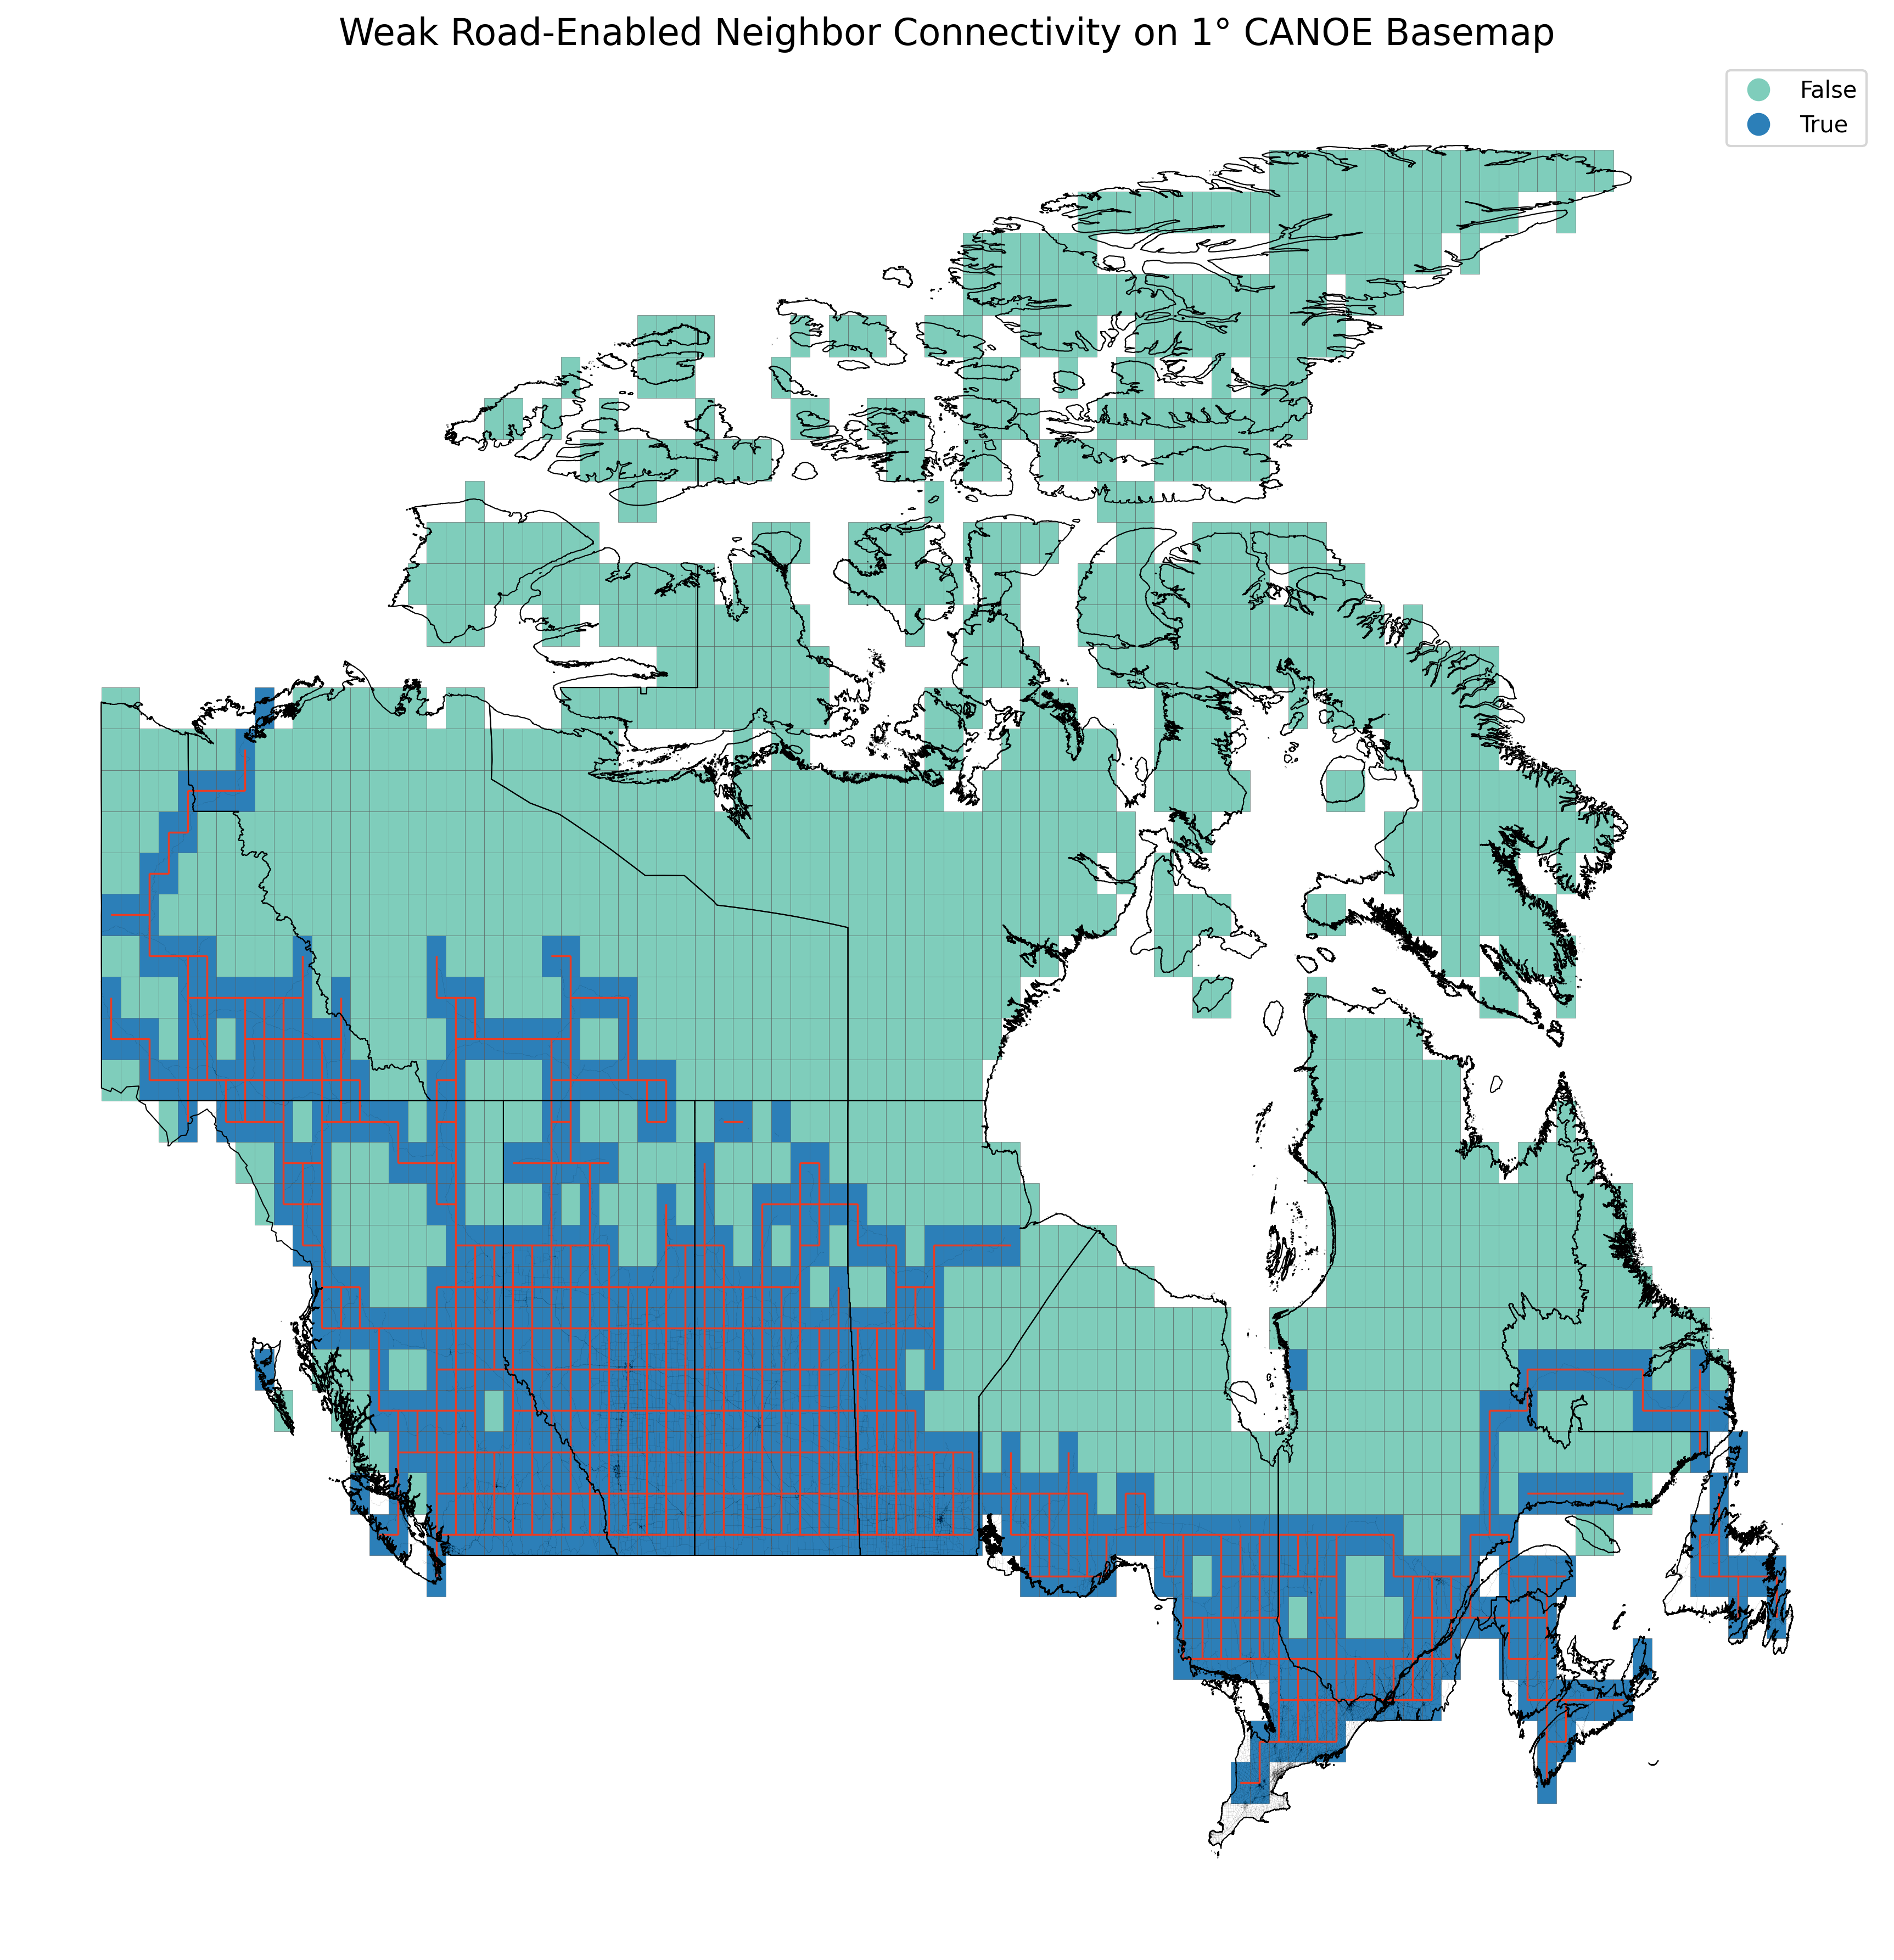

Weak road-neighbor connectivity map complete.


In [48]:
# =============================================================================
# Map weak road-neighbor connectivity
# =============================================================================

print("Mapping weak road-neighbor connectivity...")

fig, ax = plt.subplots(
    figsize=(12, 12),
    dpi=300,
)

regions_with_road_presence.plot(
    ax=ax,
    column="has_road",
    cmap=road_presence_colors,
    legend=True,
    linewidth=0.12,
    edgecolor="#4D4D4D",
    zorder=1,
)

roads_overlay.plot(
    ax=ax,
    color="black",
    linewidth=0.10,
    alpha=0.25,
    zorder=2,
)

road_edge_gdf.plot(
    ax=ax,
    color="#F03B20",
    linewidth=0.8,
    alpha=0.8,
    zorder=3,
)

canada_basemap.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
    zorder=4,
)

ax.set_title(
    "Weak Road-Enabled Neighbor Connectivity on 1° CANOE Basemap",
    fontsize=16,
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

print("Weak road-neighbor connectivity map complete.")

In [49]:
# =============================================================================
# Export weak road connectivity outputs
# =============================================================================

print("Exporting weak road connectivity outputs...")

WEAK_REGION_ROAD_PRESENCE_PATH = (
    PROCESSED_ROAD_CONNECTIVITY /
    f"{OUTPUT_STEM}_weak_region_road_presence.csv"
)

WEAK_ROAD_NEIGHBOR_CONNECTIONS_PATH = (
    PROCESSED_ROAD_CONNECTIVITY /
    f"{OUTPUT_STEM}_weak_road_neighbor_connections.csv"
)

WEAK_ROAD_EDGE_GPKG_PATH = (
    PROCESSED_ROAD_CONNECTIVITY /
    f"{OUTPUT_STEM}_weak_road_edges.gpkg"
)

region_road_presence.to_csv(
    WEAK_REGION_ROAD_PRESENCE_PATH,
    index=False,
)

road_neighbor_connections.to_csv(
    WEAK_ROAD_NEIGHBOR_CONNECTIONS_PATH,
    index=False,
)

road_edge_gdf.to_file(
    WEAK_ROAD_EDGE_GPKG_PATH,
    driver="GPKG",
)

print(f"Exported: {WEAK_REGION_ROAD_PRESENCE_PATH.name}")
print(f"Exported: {WEAK_ROAD_NEIGHBOR_CONNECTIONS_PATH.name}")
print(f"Exported: {WEAK_ROAD_EDGE_GPKG_PATH.name}")

print("Weak road connectivity export complete.")

Exporting weak road connectivity outputs...
Exported: CANADA_filtered_road_networks__canada_basemap_1deg_centroid_weak_region_road_presence.csv
Exported: CANADA_filtered_road_networks__canada_basemap_1deg_centroid_weak_road_neighbor_connections.csv
Exported: CANADA_filtered_road_networks__canada_basemap_1deg_centroid_weak_road_edges.gpkg
Weak road connectivity export complete.
